# Semana 3 — Cáncer de Mama: PCA + Clasificación + Agrupamiento K-Means / GMM
## Aprendizaje Automático Estadístico — MIAA-B · Deber Semana 3

**Asignatura:** Aprendizaje automático estadístico MIA-B
**Docente:** Ivan Danilo Garcia Santillan
**Universidad:** UIDE
**Grupo 1:**
- César Nelson Abarca Araujo
- Nataly Fernanda Lanchimba Caiza
- Jhon Enrique Oña Guamani

**Dataset:** [Breast Cancer Wisconsin (Diagnostic) — UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic) (`ucimlrepo`, id=17)
**Algoritmos Fase I:** PCA + Algoritmos Supervisados (NB, KNN, LR, DT, RF, SVM, RNA)
**Algoritmos Fase II:** K-Means y GMM

---

**Objetivo:** Aplicar PCA para reducción de dimensiones sobre las 9 variables morfológicas seleccionadas del dataset de cáncer de mama, comparar 7 algoritmos supervisados con y sin PCA, y realizar agrupamiento no supervisado con K-Means y GMM (K=2 y K=3) sobre la separación Benigno/Maligno.

**Fases:**
- **Fase I:** PCA + 7 clasificadores supervisados (NB, K-NN, LR, DT, RF, SVM, RNA) — con y sin PCA
- **Fase II:** Clustering K-Means y GMM (K=2 y K=3) — 4 métricas + comparativa final

**Contexto clínico:** Un diagnóstico erróneo tiene consecuencias críticas. Un **falso negativo** (maligno clasificado como benigno) es más costoso que un falso positivo, por lo que además del accuracy general se reportan Recall y AUC-ROC de la clase maligna en cada comparación.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, os, warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA

# Clasificadores supervisados
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Clustering
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

# Métricas — clasificación
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix)

# Métricas — clustering
from sklearn.metrics import (silhouette_score, calinski_harabasz_score,
    davies_bouldin_score)

from scipy.stats import mode

# RNA
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import sklearn
print('Librerías cargadas.')
print(f'NumPy {np.__version__} | Pandas {pd.__version__} | SKLearn {sklearn.__version__} | TF {tf.__version__}')


Librerías cargadas.
NumPy 1.26.4 | Pandas 3.0.3 | SKLearn 1.8.0 | TF 2.21.0


In [2]:
from ucimlrepo import fetch_ucirepo

# Descarga del dataset UCI ID=17 (Breast Cancer Wisconsin Diagnostic)
breast_cancer = fetch_ucirepo(id=17)

X_raw = breast_cancer.data.features.copy()
y_raw = breast_cancer.data.targets.copy()

df_raw = pd.concat([y_raw, X_raw], axis=1)
df_raw.rename(columns={df_raw.columns[0]: 'diagnosis'}, inplace=True)
df_raw['diagnosis'] = df_raw['diagnosis'].map({'M': 1, 'B': 0})

print(f'Dataset cargado: {df_raw.shape}  ({df_raw.shape[0]} filas, {df_raw.shape[1]} columnas)')
print(f'Valores nulos:\n{df_raw.isnull().sum()[df_raw.isnull().sum() > 0]}')
df_raw.head(3)


Dataset cargado: (569, 31)  (569 filas, 31 columnas)
Valores nulos:
Series([], dtype: int64)


,diagnosis,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
0,1,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758


In [3]:
df = df_raw.copy()

# Variables _mean seleccionadas (se descartan radius1/perimeter1 por colinealidad > 0.99 con area1,
# y fractal_dimension1 por correlación ~0 con diagnosis — ver Fase II de Semana 2)
cols_mean = ['texture1', 'area1', 'smoothness1', 'compactness1',
             'concavity1', 'concave_points1', 'symmetry1']

# Ingeniería de variables
df['irregularidad'] = df['compactness1'] * df['concavity1']
df['forma_nuclear']  = df['concave_points1'] / (df['smoothness1'] + 1e-6)

FEATURES = cols_mean + ['irregularidad', 'forma_nuclear']
TARGET   = 'diagnosis'

X = df[FEATURES].values
y = df[TARGET].values

print(f'Features ({len(FEATURES)}): {FEATURES}')
print(f'X shape: {X.shape} | y shape: {y.shape}')
print(f'Malignos: {y.sum()} ({100*y.mean():.1f}%)  |  Benignos: {(1-y).sum()} ({100*(1-y).mean():.1f}%)')
df[FEATURES + [TARGET]].head(4)


Features (9): ['texture1', 'area1', 'smoothness1', 'compactness1', 'concavity1', 'concave_points1', 'symmetry1', 'irregularidad', 'forma_nuclear']
X shape: (569, 9) | y shape: (569,)
Malignos: 212 (37.3%)  |  Benignos: 357 (62.7%)


,texture1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,irregularidad,forma_nuclear,diagnosis
0,10.38,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.083308,1.242388,1
1,17.77,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.006834,0.828053,1
2,21.25,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.031564,1.166960,1
3,20.38,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.068533,0.738240,1


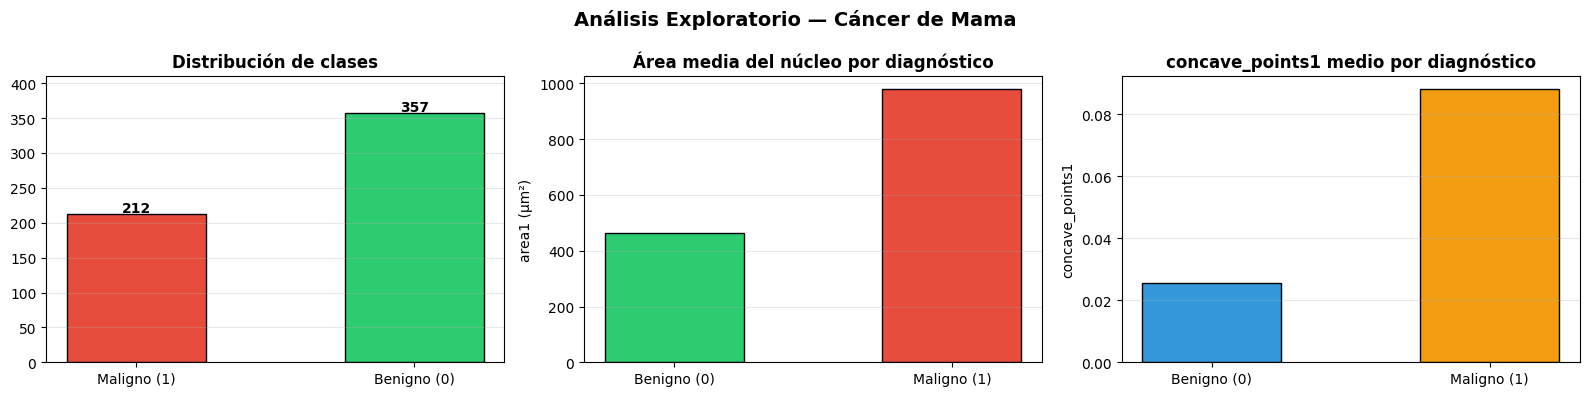

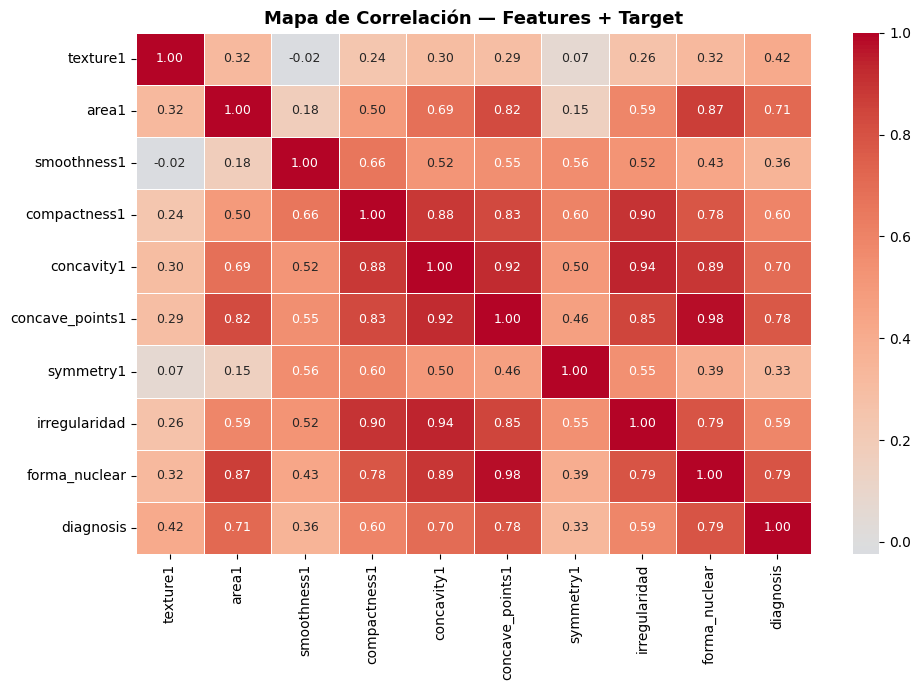

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Distribución de clases
counts = [y.sum(), (1-y).sum()]
bars = axes[0].bar(['Maligno (1)', 'Benigno (0)'], counts,
                   color=['#e74c3c','#2ecc71'], edgecolor='black', width=0.5)
axes[0].set_title('Distribución de clases', fontweight='bold')
for bar, v in zip(bars, counts):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+3,
                 str(v), ha='center', fontweight='bold')
axes[0].set_ylim(0, max(counts)*1.15)
axes[0].grid(axis='y', alpha=0.3)

# Área media por diagnóstico
area_diag = df.groupby('diagnosis')['area1'].mean()
axes[1].bar(['Benigno (0)', 'Maligno (1)'], area_diag.values,
            color=['#2ecc71','#e74c3c'], edgecolor='black', width=0.5)
axes[1].set_title('Área media del núcleo por diagnóstico', fontweight='bold')
axes[1].set_ylabel('area1 (µm²)')
axes[1].grid(axis='y', alpha=0.3)

# concave_points1 medio por diagnóstico (mejor predictor individual)
cp_diag = df.groupby('diagnosis')['concave_points1'].mean()
axes[2].bar(['Benigno (0)', 'Maligno (1)'], cp_diag.values,
            color=['#3498db','#f39c12'], edgecolor='black', width=0.5)
axes[2].set_title('concave_points1 medio por diagnóstico', fontweight='bold')
axes[2].set_ylabel('concave_points1')
axes[2].grid(axis='y', alpha=0.3)

plt.suptitle('Análisis Exploratorio — Cáncer de Mama', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_eda_cancer_s3.png', bbox_inches='tight')
plt.show()

# Correlación
plt.figure(figsize=(10, 7))
corr = pd.DataFrame(X, columns=FEATURES)
corr['diagnosis'] = y
sns.heatmap(corr.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.4, annot_kws={'size': 9})
plt.title('Mapa de Correlación — Features + Target', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_correlacion_s3.png', bbox_inches='tight')
plt.show()


## Interpretación

El dataset presenta un desbalance moderado: 37.3% de casos malignos (212) frente a 62.7% benignos (357). No es un desbalance severo. Por otro lado, en el mapa de correlación se visualiza que los tumores malignos tienen, en promedio, mayor área nuclear y mayor concave_points1 que los benignos, lo cual es consistente con la biología del cáncer (núcleos más grandes e irregulares en tejido maligno). El mapa de correlación confirma la lógica detrás de la ingeniería de variables de la celda 3: concavity1 y concave_points1 están correlacionadas entre sí y con el target, lo que motiva combinarlas en irregularidad y forma_nuclear para reducir redundancia sin perder señal.

---
## PCA — Reducción de Dimensiones

**PCA** transforma las 9 características morfológicas en componentes ortogonales ordenados por varianza.

**Motivación:** Varias características están correlacionadas entre sí (ej. `concavity1` ↔ `irregularidad`, `concave_points1` ↔ `forma_nuclear`). PCA elimina esa redundancia y permite:
- Visualizar la separabilidad de clases (maligno vs benigno) en 2D
- Comparar si los clasificadores mejoran o empeoran con espacio reducido

**Buena práctica:** PCA se ajusta **solo** con X_train → se transforma X_test con el mismo objeto.


Componentes necesarios por umbral de varianza acumulada:
  70%: 2 componentes
  80%: 3 componentes
  90%: 4 componentes
  95%: 5 componentes

PC1: 64.73%  |  PC2: 15.11%  |  PC1+PC2: 79.84%


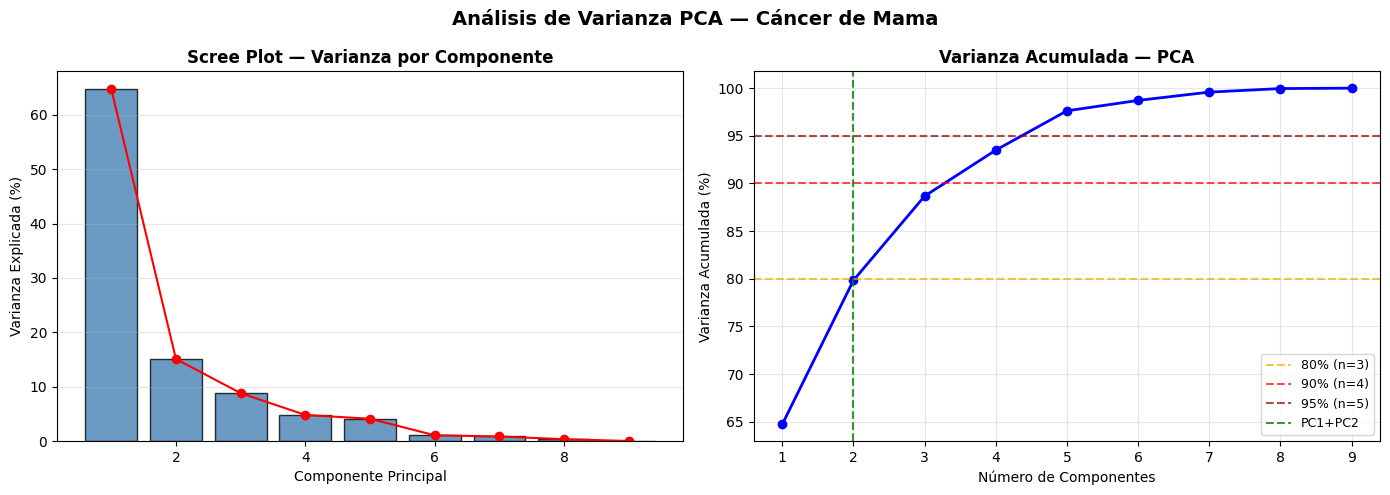

In [5]:
# Escalar globalmente para análisis de varianza
scaler_global = StandardScaler()
X_scaled_all = scaler_global.fit_transform(X)

pca_full = PCA(n_components=X.shape[1])
pca_full.fit(X_scaled_all)
var_exp = pca_full.explained_variance_ratio_
var_cum = np.cumsum(var_exp)

print('Componentes necesarios por umbral de varianza acumulada:')
for u in [0.70, 0.80, 0.90, 0.95]:
    n = np.argmax(var_cum >= u) + 1
    print(f'  {int(u*100)}%: {n} componentes')
print(f'\nPC1: {var_exp[0]*100:.2f}%  |  PC2: {var_exp[1]*100:.2f}%  |  PC1+PC2: {var_cum[1]*100:.2f}%')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, len(var_exp)+1), var_exp*100, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].plot(range(1, len(var_exp)+1), var_exp*100, 'ro-', markersize=6)
axes[0].set_title('Scree Plot — Varianza por Componente', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Componente Principal')
axes[0].set_ylabel('Varianza Explicada (%)')
axes[0].grid(axis='y', alpha=0.3)

axes[1].plot(range(1, len(var_cum)+1), var_cum*100, 'bo-', markersize=6, linewidth=2)
for p, c in [(0.80,'orange'), (0.90,'red'), (0.95,'darkred')]:
    n = np.argmax(var_cum >= p) + 1
    axes[1].axhline(y=p*100, color=c, linestyle='--', alpha=0.7, label=f'{int(p*100)}% (n={n})')
axes[1].axvline(x=2, color='green', linestyle='--', alpha=0.8, label='PC1+PC2')
axes[1].set_title('Varianza Acumulada — PCA', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Número de Componentes')
axes[1].set_ylabel('Varianza Acumulada (%)')
axes[1].legend(loc='lower right', fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Análisis de Varianza PCA — Cáncer de Mama', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_pca_varianza_s3.png', bbox_inches='tight')
plt.show()


## Interpretación

Se puede notar que con solo 2 componentes se retiene el 79.84% de la varianza (PC1=64.73%, PC2=15.11%), y se necesitan apenas 3 componentes para superar el 80%. Esto es señal de alta multicolinealidad entre las 9 variables morfológicas (ya detectada en la Semana 2), y anticipa por qué —a diferencia de Titanic— reducir a 2 dimensiones aquí va a perder relativamente poca información predictiva.

In [ ]:
pca_viz = PCA(n_components=2, random_state=101699)
X_pca_viz = pca_viz.fit_transform(X_scaled_all)

plt.figure(figsize=(9, 6))
scatter = plt.scatter(X_pca_viz[:, 0], X_pca_viz[:, 1],
                      c=y, cmap='coolwarm', alpha=0.7, edgecolors='k', linewidth=0.3, s=50)
plt.xlabel(f'PC1 ({pca_viz.explained_variance_ratio_[0]*100:.1f}% varianza)', fontsize=12)
plt.ylabel(f'PC2 ({pca_viz.explained_variance_ratio_[1]*100:.1f}% varianza)', fontsize=12)
plt.title('Proyección PCA 2D — Cáncer de Mama (maligno vs benigno)', fontsize=14, fontweight='bold')
plt.legend(handles=scatter.legend_elements()[0],
           labels=['Benigno (0)', 'Maligno (1)'], fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig_pca_2d_s3.png', bbox_inches='tight')
plt.show()
print('Los grupos se separan razonablemente bien en PCA 2D, aunque persiste una zona de solapamiento.')


In [6]:
SEED = 101699

# Split 80/20 estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

# StandardScaler (NB, KNN, LR, DT, RF, SVM) — ajustado solo en train
sc = StandardScaler()
X_train_sc = sc.fit_transform(X_train)
X_test_sc  = sc.transform(X_test)

# PCA 2 componentes — ajustado solo en train_sc
pca = PCA(n_components=2, random_state=SEED)
X_train_pca = pca.fit_transform(X_train_sc)
X_test_pca  = pca.transform(X_test_sc)

# MinMaxScaler para RNA — ajustado solo en train
sc_rna = MinMaxScaler()
X_train_rna = sc_rna.fit_transform(X_train)
X_test_rna  = sc_rna.transform(X_test)

# MinMaxScaler sobre features PCA para RNA+PCA
sc_rna_pca = MinMaxScaler()
X_train_rna_pca = sc_rna_pca.fit_transform(X_train_pca)
X_test_rna_pca  = sc_rna_pca.transform(X_test_pca)

print(f'X_train (sin PCA): {X_train_sc.shape}    X_test: {X_test_sc.shape}')
print(f'X_train (con PCA): {X_train_pca.shape}    X_test: {X_test_pca.shape}')
print(f'Train Malignos: {y_train.sum()} ({100*y_train.mean():.1f}%)  |  Test: {y_test.sum()} ({100*y_test.mean():.1f}%)')


X_train (sin PCA): (455, 9)    X_test: (114, 9)
X_train (con PCA): (455, 2)    X_test: (114, 2)
Train Malignos: 170 (37.4%)  |  Test: 42 (36.8%)


In [7]:
def evaluar(nombre, modelo, X_tr, X_te, y_tr, y_te, cv=5):
    modelo.fit(X_tr, y_tr)
    y_pred = modelo.predict(X_te)
    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, zero_division=0)
    rec  = recall_score(y_te, y_pred, zero_division=0)
    f1   = f1_score(y_te, y_pred, zero_division=0)
    if hasattr(modelo, 'predict_proba'):
        y_prob = modelo.predict_proba(X_te)[:, 1]
    else:
        y_prob = modelo.decision_function(X_te)
        y_prob = (y_prob - y_prob.min()) / (y_prob.max() - y_prob.min() + 1e-10)
    auc = roc_auc_score(y_te, y_prob)
    cv_s = cross_val_score(modelo, X_tr, y_tr, cv=cv, scoring='accuracy')
    print(f"\n{'='*52}")
    print(f' {nombre}')
    print(f"{'='*52}")
    print(f'  CV Accuracy (5-fold): {cv_s.mean()*100:.2f}% ± {cv_s.std()*100:.2f}%')
    print(f'  Test Accuracy       : {acc*100:.2f}%')
    print(f'  Precision           : {prec*100:.2f}%')
    print(f'  Recall              : {rec*100:.2f}%')
    print(f'  F1-Score            : {f1*100:.2f}%')
    print(f'  AUC-ROC             : {auc*100:.2f}%')
    return {'Modelo':nombre,'CV Acc%':round(cv_s.mean()*100,2),
            'Test Acc%':round(acc*100,2),'Prec%':round(prec*100,2),
            'Recall%':round(rec*100,2),'F1%':round(f1*100,2),'AUC%':round(auc*100,2)}

res = []  # acumula resultados Fase I
print('Función evaluar() definida.')


Función evaluar() definida.


---
## Fase I — Clasificación Supervisada con y sin PCA

Se comparan **7 algoritmos** en dos condiciones:
- **Sin PCA:** 9 features escaladas con StandardScaler (o MinMaxScaler para RNA)
- **Con PCA:** 2 componentes principales derivados de esas 9 features

| # | Algoritmo | Abrev. |
|---|-----------|--------|
| 1 | Naive Bayes | NB |
| 2 | K-Nearest Neighbors | KNN |
| 3 | Regresión Logística | LR |
| 4 | Árbol de Decisión | DT |
| 5 | Bosque Aleatorio | RF |
| 6 | Máquina de Vectores de Soporte | SVM |
| 7 | Red Neuronal Artificial | RNA |


In [8]:
nb_base = GaussianNB()
r = evaluar('NB — Sin PCA', nb_base, X_train_sc, X_test_sc, y_train, y_test)
res.append(r)



 NB — Sin PCA
  CV Accuracy (5-fold): 92.31% ± 1.97%
  Test Accuracy       : 92.98%
  Precision           : 90.48%
  Recall              : 90.48%
  F1-Score            : 90.48%
  AUC-ROC             : 98.08%


In [9]:
nb_pca = GaussianNB()
r = evaluar('NB — Con PCA', nb_pca, X_train_pca, X_test_pca, y_train, y_test)
res.append(r)



 NB — Con PCA
  CV Accuracy (5-fold): 90.33% ± 2.54%
  Test Accuracy       : 91.23%
  Precision           : 92.11%
  Recall              : 83.33%
  F1-Score            : 87.50%
  AUC-ROC             : 98.31%


In [10]:
knn_base = KNeighborsClassifier(n_neighbors=5, p=2)
r = evaluar('KNN — Sin PCA', knn_base, X_train_sc, X_test_sc, y_train, y_test)
res.append(r)



 KNN — Sin PCA
  CV Accuracy (5-fold): 94.29% ± 1.76%
  Test Accuracy       : 93.86%
  Precision           : 85.71%
  Recall              : 100.00%
  F1-Score            : 92.31%
  AUC-ROC             : 99.36%


In [11]:
knn_pca = KNeighborsClassifier(n_neighbors=5, p=2)
r = evaluar('KNN — Con PCA', knn_pca, X_train_pca, X_test_pca, y_train, y_test)
res.append(r)



 KNN — Con PCA
  CV Accuracy (5-fold): 91.87% ± 2.04%
  Test Accuracy       : 91.23%
  Precision           : 84.78%
  Recall              : 92.86%
  F1-Score            : 88.64%
  AUC-ROC             : 96.33%


In [12]:
lr_base = LogisticRegression(max_iter=1000, random_state=SEED)
r = evaluar('LR — Sin PCA', lr_base, X_train_sc, X_test_sc, y_train, y_test)
res.append(r)



 LR — Sin PCA
  CV Accuracy (5-fold): 92.75% ± 2.66%
  Test Accuracy       : 96.49%
  Precision           : 93.18%
  Recall              : 97.62%
  F1-Score            : 95.35%
  AUC-ROC             : 99.64%


In [13]:
lr_pca = LogisticRegression(max_iter=1000, random_state=SEED)
r = evaluar('LR — Con PCA', lr_pca, X_train_pca, X_test_pca, y_train, y_test)
res.append(r)



 LR — Con PCA
  CV Accuracy (5-fold): 92.31% ± 2.78%
  Test Accuracy       : 94.74%
  Precision           : 90.91%
  Recall              : 95.24%
  F1-Score            : 93.02%
  AUC-ROC             : 99.04%


In [14]:
dt_base = DecisionTreeClassifier(max_depth=4, criterion='gini', random_state=SEED)
r = evaluar('DT — Sin PCA', dt_base, X_train_sc, X_test_sc, y_train, y_test)
res.append(r)



 DT — Sin PCA
  CV Accuracy (5-fold): 90.11% ± 3.93%
  Test Accuracy       : 89.47%
  Precision           : 84.09%
  Recall              : 88.10%
  F1-Score            : 86.05%
  AUC-ROC             : 92.94%


In [15]:
dt_pca = DecisionTreeClassifier(max_depth=4, criterion='gini', random_state=SEED)
r = evaluar('DT — Con PCA', dt_pca, X_train_pca, X_test_pca, y_train, y_test)
res.append(r)



 DT — Con PCA
  CV Accuracy (5-fold): 88.57% ± 2.92%
  Test Accuracy       : 92.11%
  Precision           : 92.31%
  Recall              : 85.71%
  F1-Score            : 88.89%
  AUC-ROC             : 96.61%


In [16]:
rf_base = RandomForestClassifier(n_estimators=100, max_depth=6, criterion='entropy', random_state=SEED)
r = evaluar('RF — Sin PCA', rf_base, X_train_sc, X_test_sc, y_train, y_test)
res.append(r)



 RF — Sin PCA
  CV Accuracy (5-fold): 92.97% ± 1.32%
  Test Accuracy       : 93.86%
  Precision           : 88.89%
  Recall              : 95.24%
  F1-Score            : 91.95%
  AUC-ROC             : 98.74%


In [17]:
rf_pca = RandomForestClassifier(n_estimators=100, max_depth=6, criterion='entropy', random_state=SEED)
r = evaluar('RF — Con PCA', rf_pca, X_train_pca, X_test_pca, y_train, y_test)
res.append(r)



 RF — Con PCA
  CV Accuracy (5-fold): 90.99% ± 2.73%
  Test Accuracy       : 92.11%
  Precision           : 86.67%
  Recall              : 92.86%
  F1-Score            : 89.66%
  AUC-ROC             : 98.64%


In [18]:
svm_base = SVC(kernel='linear', C=1.0, gamma='scale', probability=True, random_state=SEED)
r = evaluar('SVM — Sin PCA', svm_base, X_train_sc, X_test_sc, y_train, y_test)
res.append(r)



 SVM — Sin PCA
  CV Accuracy (5-fold): 91.65% ± 2.75%
  Test Accuracy       : 96.49%
  Precision           : 95.24%
  Recall              : 95.24%
  F1-Score            : 95.24%
  AUC-ROC             : 99.34%


In [19]:
svm_pca = SVC(kernel='linear', C=1.0, gamma='scale', probability=True, random_state=SEED)
r = evaluar('SVM — Con PCA', svm_pca, X_train_pca, X_test_pca, y_train, y_test)
res.append(r)



 SVM — Con PCA
  CV Accuracy (5-fold): 92.53% ± 2.81%
  Test Accuracy       : 94.74%
  Precision           : 90.91%
  Recall              : 95.24%
  F1-Score            : 93.02%
  AUC-ROC             : 99.11%


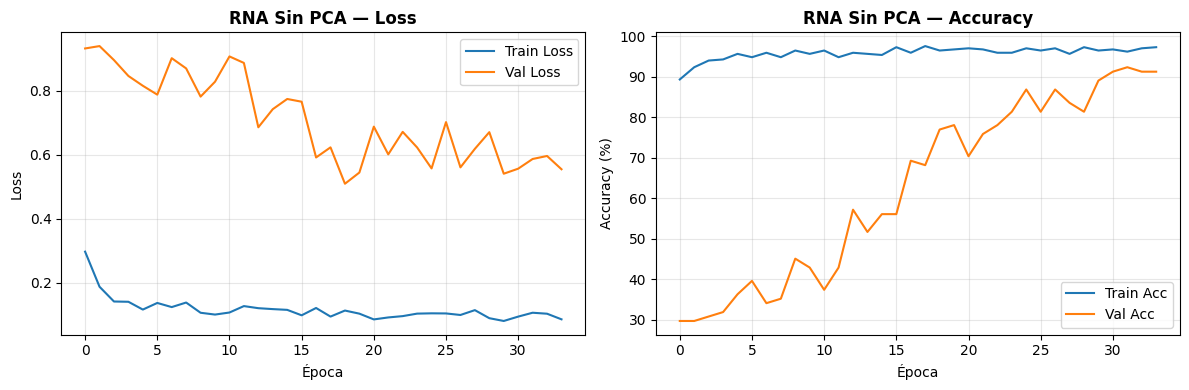


===== RNA — Sin PCA =====
  Test Accuracy: 83.33%
  Precision    : 68.85%
  Recall       : 100.00%
  F1-Score     : 81.55%
  AUC-ROC      : 99.70%
  Épocas ejecutadas: 34


In [20]:
tf.random.set_seed(SEED)
np.random.seed(SEED)

rna_base = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_rna.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])
rna_base.compile(optimizer=Adam(learning_rate=1e-2),
                 loss='binary_crossentropy', metrics=['accuracy'])

cb = [EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
      ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, verbose=0)]

hist_base = rna_base.fit(X_train_rna, y_train, epochs=150, batch_size=32,
                         validation_split=0.2, callbacks=cb, verbose=0)

plt.figure(figsize=(12, 4))
plt.subplot(1,2,1)
plt.plot(hist_base.history['loss'], label='Train Loss')
plt.plot(hist_base.history['val_loss'], label='Val Loss')
plt.title('RNA Sin PCA — Loss', fontweight='bold')
plt.xlabel('Época'); plt.ylabel('Loss'); plt.legend(); plt.grid(alpha=0.3)
plt.subplot(1,2,2)
plt.plot([a*100 for a in hist_base.history['accuracy']], label='Train Acc')
plt.plot([a*100 for a in hist_base.history['val_accuracy']], label='Val Acc')
plt.title('RNA Sin PCA — Accuracy', fontweight='bold')
plt.xlabel('Época'); plt.ylabel('Accuracy (%)'); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('fig_rna_sin_pca_s3.png', bbox_inches='tight'); plt.show()

y_prob_rna = rna_base.predict(X_test_rna, verbose=0).ravel()
y_pred_rna = (y_prob_rna >= 0.5).astype(int)
acc  = accuracy_score(y_test, y_pred_rna)
prec = precision_score(y_test, y_pred_rna, zero_division=0)
rec  = recall_score(y_test, y_pred_rna, zero_division=0)
f1   = f1_score(y_test, y_pred_rna, zero_division=0)
auc  = roc_auc_score(y_test, y_prob_rna)
print(f'\n===== RNA — Sin PCA =====')
print(f'  Test Accuracy: {acc*100:.2f}%')
print(f'  Precision    : {prec*100:.2f}%')
print(f'  Recall       : {rec*100:.2f}%')
print(f'  F1-Score     : {f1*100:.2f}%')
print(f'  AUC-ROC      : {auc*100:.2f}%')
print(f'  Épocas ejecutadas: {len(hist_base.history["loss"])}')
res.append({'Modelo':'RNA — Sin PCA','CV Acc%': round(acc*100,2),
            'Test Acc%':round(acc*100,2),'Prec%':round(prec*100,2),
            'Recall%':round(rec*100,2),'F1%':round(f1*100,2),'AUC%':round(auc*100,2)})


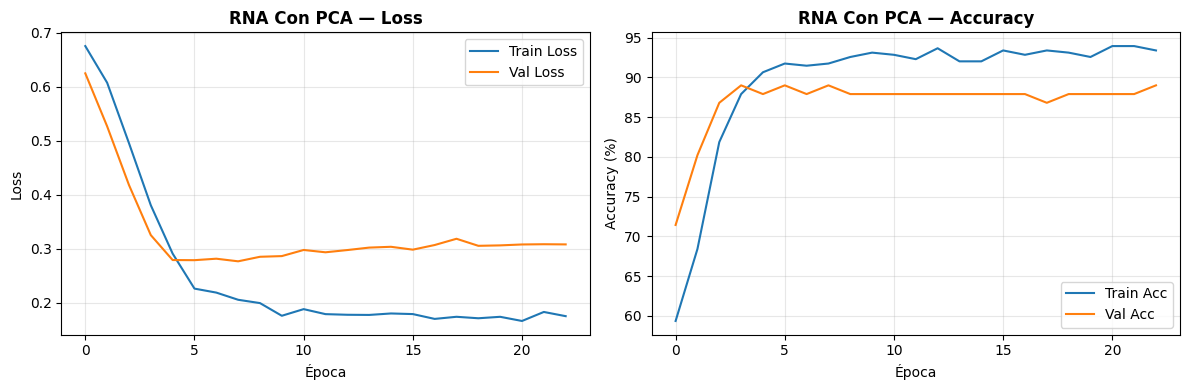


===== RNA — Con PCA =====
  Test Accuracy: 96.49%
  Precision    : 91.30%
  Recall       : 100.00%
  F1-Score     : 95.45%
  AUC-ROC      : 99.07%
  Épocas ejecutadas: 23


In [21]:
tf.random.set_seed(SEED)
np.random.seed(SEED)

rna_pca = Sequential([
    Dense(16, activation='relu', input_shape=(X_train_rna_pca.shape[1],)),
    Dropout(0.2),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])
rna_pca.compile(optimizer=Adam(learning_rate=1e-2),
                loss='binary_crossentropy', metrics=['accuracy'])

cb2 = [EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
       ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, verbose=0)]

hist_pca = rna_pca.fit(X_train_rna_pca, y_train, epochs=150, batch_size=32,
                        validation_split=0.2, callbacks=cb2, verbose=0)

plt.figure(figsize=(12, 4))
plt.subplot(1,2,1)
plt.plot(hist_pca.history['loss'], label='Train Loss')
plt.plot(hist_pca.history['val_loss'], label='Val Loss')
plt.title('RNA Con PCA — Loss', fontweight='bold')
plt.xlabel('Época'); plt.ylabel('Loss'); plt.legend(); plt.grid(alpha=0.3)
plt.subplot(1,2,2)
plt.plot([a*100 for a in hist_pca.history['accuracy']], label='Train Acc')
plt.plot([a*100 for a in hist_pca.history['val_accuracy']], label='Val Acc')
plt.title('RNA Con PCA — Accuracy', fontweight='bold')
plt.xlabel('Época'); plt.ylabel('Accuracy (%)'); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('fig_rna_con_pca_s3.png', bbox_inches='tight'); plt.show()

y_prob_rna_pca = rna_pca.predict(X_test_rna_pca, verbose=0).ravel()
y_pred_rna_pca = (y_prob_rna_pca >= 0.5).astype(int)
acc2  = accuracy_score(y_test, y_pred_rna_pca)
prec2 = precision_score(y_test, y_pred_rna_pca, zero_division=0)
rec2  = recall_score(y_test, y_pred_rna_pca, zero_division=0)
f12   = f1_score(y_test, y_pred_rna_pca, zero_division=0)
auc2  = roc_auc_score(y_test, y_prob_rna_pca)
print(f'\n===== RNA — Con PCA =====')
print(f'  Test Accuracy: {acc2*100:.2f}%')
print(f'  Precision    : {prec2*100:.2f}%')
print(f'  Recall       : {rec2*100:.2f}%')
print(f'  F1-Score     : {f12*100:.2f}%')
print(f'  AUC-ROC      : {auc2*100:.2f}%')
print(f'  Épocas ejecutadas: {len(hist_pca.history["loss"])}')
res.append({'Modelo':'RNA — Con PCA','CV Acc%':round(acc2*100,2),
            'Test Acc%':round(acc2*100,2),'Prec%':round(prec2*100,2),
            'Recall%':round(rec2*100,2),'F1%':round(f12*100,2),'AUC%':round(auc2*100,2)})


In [22]:
df_f1 = pd.DataFrame(res)
df_f1.insert(1, 'PCA', ['Sin PCA','Con PCA']*7)

print('\nTabla comparativa Fase I — 7 algoritmos con y sin PCA')
print('='*80)
print(df_f1[['Modelo','PCA','CV Acc%','Test Acc%','Prec%','Recall%','F1%','AUC%']].to_string(index=False))
print('='*80)
print(f'\nMejor Test Accuracy: {df_f1.loc[df_f1["Test Acc%"].idxmax(),"Modelo"]}  ({df_f1["Test Acc%"].max():.2f}%)')
print(f'Mejor AUC-ROC      : {df_f1.loc[df_f1["AUC%"].idxmax(),"Modelo"]}  ({df_f1["AUC%"].max():.2f}%)')
print(f'Mejor F1-Score     : {df_f1.loc[df_f1["F1%"].idxmax(),"Modelo"]}  ({df_f1["F1%"].max():.2f}%)')



Tabla comparativa Fase I — 7 algoritmos con y sin PCA
       Modelo     PCA  CV Acc%  Test Acc%  Prec%  Recall%   F1%  AUC%
 NB — Sin PCA Sin PCA    92.31      92.98  90.48    90.48 90.48 98.08
 NB — Con PCA Con PCA    90.33      91.23  92.11    83.33 87.50 98.31
KNN — Sin PCA Sin PCA    94.29      93.86  85.71   100.00 92.31 99.36
KNN — Con PCA Con PCA    91.87      91.23  84.78    92.86 88.64 96.33
 LR — Sin PCA Sin PCA    92.75      96.49  93.18    97.62 95.35 99.64
 LR — Con PCA Con PCA    92.31      94.74  90.91    95.24 93.02 99.04
 DT — Sin PCA Sin PCA    90.11      89.47  84.09    88.10 86.05 92.94
 DT — Con PCA Con PCA    88.57      92.11  92.31    85.71 88.89 96.61
 RF — Sin PCA Sin PCA    92.97      93.86  88.89    95.24 91.95 98.74
 RF — Con PCA Con PCA    90.99      92.11  86.67    92.86 89.66 98.64
SVM — Sin PCA Sin PCA    91.65      96.49  95.24    95.24 95.24 99.34
SVM — Con PCA Con PCA    92.53      94.74  90.91    95.24 93.02 99.11
RNA — Sin PCA Sin PCA    83.33     

## Interpretación

Los tres modelos con mejor desempeño (LR y SVM sin PCA, y RNA con PCA) superan 95% de Accuracy, lo que indica que el problema es casi linealmente separable en el espacio de 9 variables. Por otro lado, el RNA sin PCA es el modelo más débil con un Accuracy de 83.33%.

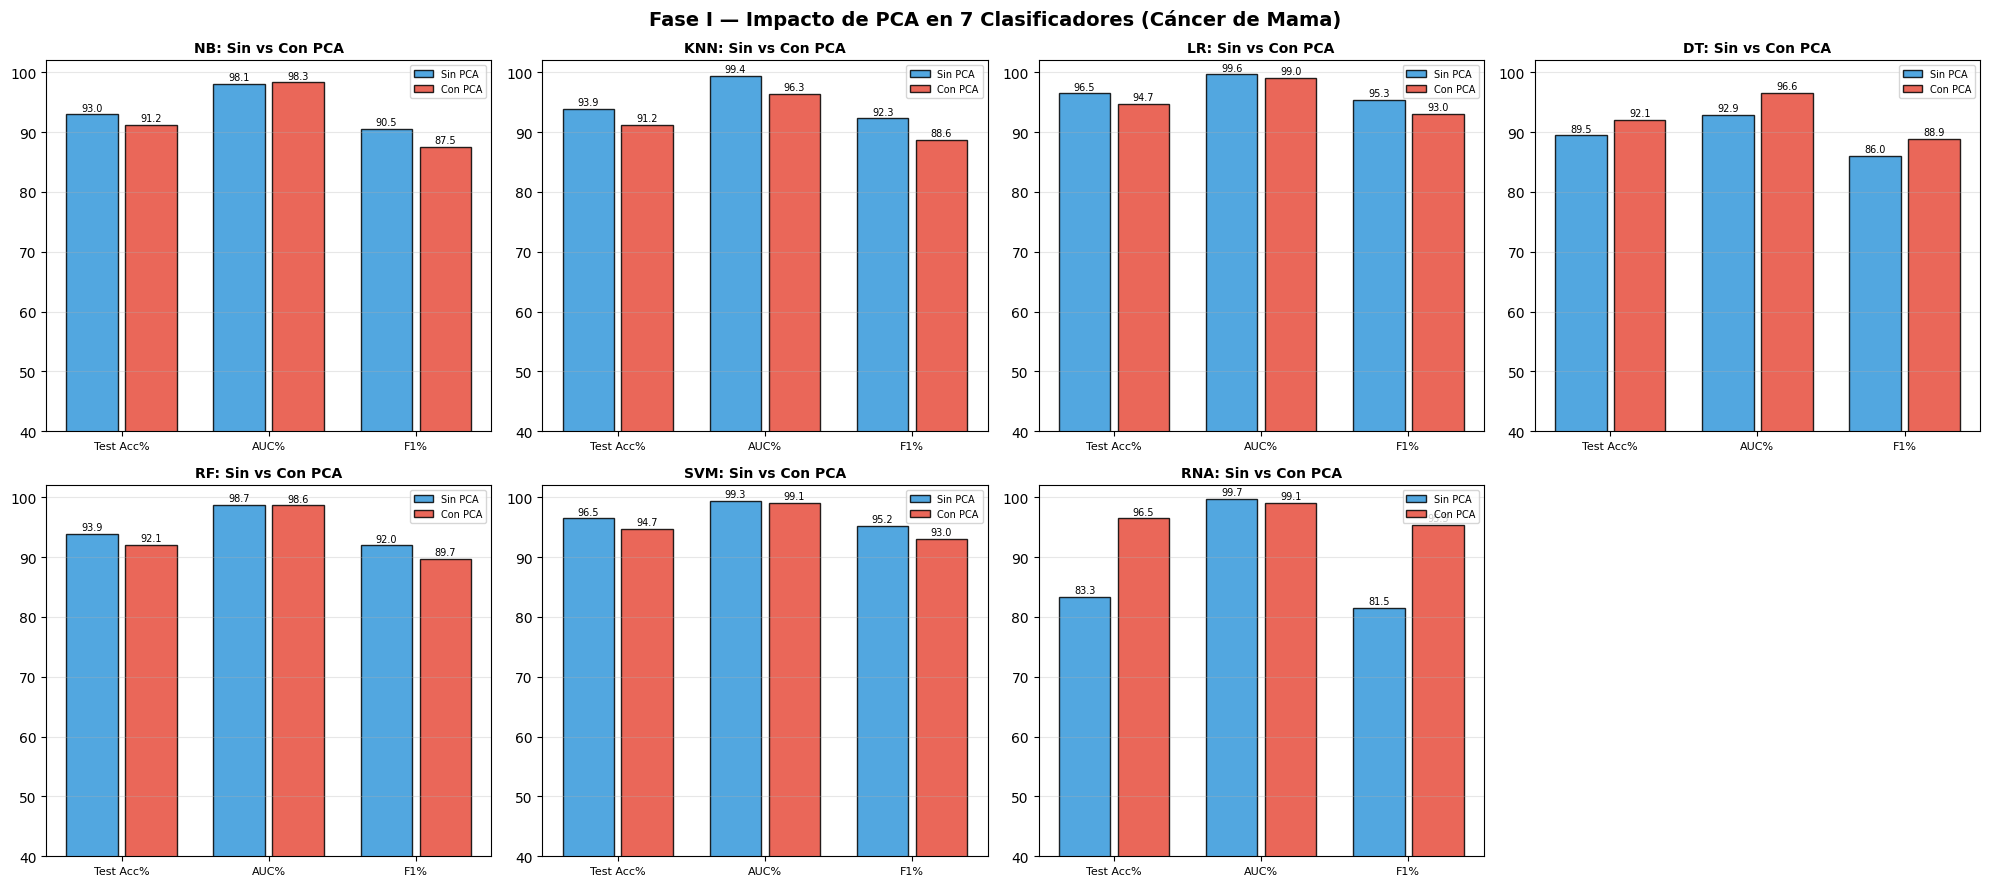

In [23]:
algoritmos = ['NB', 'KNN', 'LR', 'DT', 'RF', 'SVM', 'RNA']
metricas_plot = ['Test Acc%', 'AUC%', 'F1%']

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()

for idx, (algo, ax) in enumerate(zip(algoritmos, axes)):
    sub = df_f1[df_f1['Modelo'].str.startswith(algo)]
    sin_pca = sub[sub['PCA']=='Sin PCA'][metricas_plot].values
    con_pca = sub[sub['PCA']=='Con PCA'][metricas_plot].values
    if len(sin_pca)==0 or len(con_pca)==0:
        ax.set_visible(False); continue
    sin_pca = sin_pca[0]; con_pca = con_pca[0]
    x = np.arange(len(metricas_plot))
    b1 = ax.bar(x-0.2, sin_pca, 0.35, label='Sin PCA', color='#3498db', edgecolor='black', alpha=0.85)
    b2 = ax.bar(x+0.2, con_pca, 0.35, label='Con PCA', color='#e74c3c', edgecolor='black', alpha=0.85)
    for bar in b1:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=7)
    for bar in b2:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=7)
    ax.set_title(f'{algo}: Sin vs Con PCA', fontsize=10, fontweight='bold')
    ax.set_xticks(x); ax.set_xticklabels(metricas_plot, fontsize=8)
    ax.set_ylim(40, 102); ax.legend(fontsize=7); ax.grid(axis='y', alpha=0.3)

axes[-1].set_visible(False)
plt.suptitle('Fase I — Impacto de PCA en 7 Clasificadores (Cáncer de Mama)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_comparativa_fase1_s3.png', bbox_inches='tight')
plt.show()


In [24]:
joblib.dump(rf_base,  'rf_cancer_sin_pca.pkl')
joblib.dump(svm_base, 'svm_cancer_sin_pca.pkl')
joblib.dump(sc,       'scaler_std_f1.pkl')
joblib.dump(pca,      'pca_2comp_f1.pkl')
rna_base.save('rna_cancer_sin_pca.h5')

print('Modelos Fase I guardados:')
print('  rf_cancer_sin_pca.pkl   | svm_cancer_sin_pca.pkl')
print('  scaler_std_f1.pkl       | pca_2comp_f1.pkl')
print('  rna_cancer_sin_pca.h5')


Modelos Fase I guardados:
  rf_cancer_sin_pca.pkl   | svm_cancer_sin_pca.pkl
  scaler_std_f1.pkl       | pca_2comp_f1.pkl
  rna_cancer_sin_pca.h5


## Interpretación

La caída de desempeño con PCA es pequeña y homogénea entre modelos (entre -0.88 y -2.63 pp), y el Árbol de Decisión es la única excepción que mejora, mientras que en RNA el aplicar PCA si mejora el rendimiento del modelo en el Accuracy de la data de prueba.

---
## Fase II — Agrupamiento No Supervisado: K-Means y GMM

Los algoritmos de clustering se aplican **sin usar las etiquetas** (`diagnosis`). Con K=2, los grupos esperados corresponden a benigno/maligno; con K=3 se exploran subgrupos naturales dentro de esas categorías (por ejemplo, tumores malignos de distinto grado de agresividad morfológica).

### Métricas de evaluación interna

| Métrica | Ideal | Escala |
|---------|-------|--------|
| Inercia | ↓ Más baja | ≥ 0 |
| Silhouette Score | ↑ Más alta | -1 a 1 |
| Calinski-Harabasz | ↑ Más alta | ≥ 0 |
| Davies-Bouldin | ↓ Más baja | ≥ 0 |

### Plan
1. Método del codo (K=1..10) para justificar K=2
2. K-Means K=2 → métricas + visualización
3. K-Means K=3 → métricas + visualización
4. GMM K=2 → métricas + visualización
5. GMM K=3 → métricas + visualización
6. Comparativa: K-Means K=2 vs K=3 | GMM K=2 vs K=3
7. Mejor K-Means vs Mejor GMM


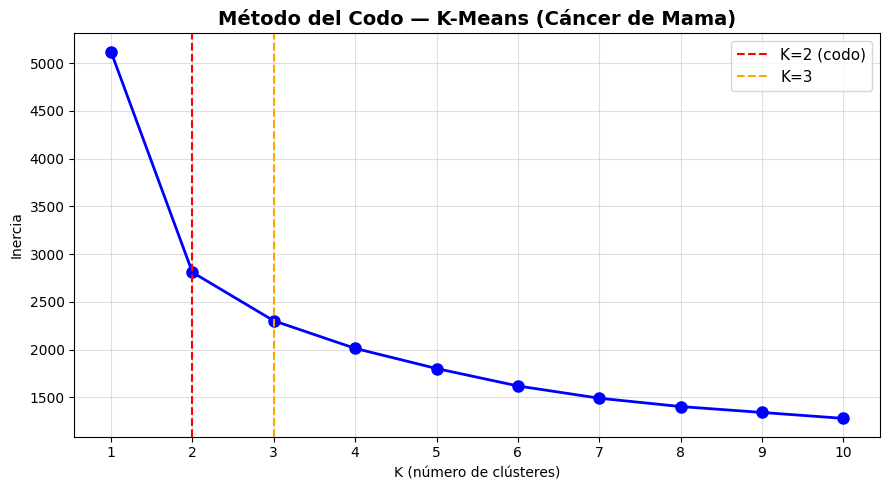

Inercias:
  K=1: 5121.0
  K=2: 2810.1
  K=3: 2302.8
  K=4: 2013.7
  K=5: 1802.8
  K=6: 1620.2
  K=7: 1491.9
  K=8: 1404.6
  K=9: 1342.8
  K=10: 1280.6


In [25]:
sc_clust = StandardScaler()
X_sc_all = sc_clust.fit_transform(X)

pca_c = PCA(n_components=2, random_state=SEED)
X_pca_c = pca_c.fit_transform(X_sc_all)

inercias_c = []
k_rng = range(1, 11)
for k in k_rng:
    km = KMeans(n_clusters=k, init='k-means++', random_state=SEED, n_init=10)
    km.fit(X_sc_all)
    inercias_c.append(km.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(k_rng, inercias_c, 'bo-', markersize=8, linewidth=2)
plt.axvline(x=2, color='red', linestyle='--', linewidth=1.5, label='K=2 (codo)')
plt.axvline(x=3, color='orange', linestyle='--', linewidth=1.5, label='K=3')
plt.title('Método del Codo — K-Means (Cáncer de Mama)', fontsize=14, fontweight='bold')
plt.xlabel('K (número de clústeres)'); plt.ylabel('Inercia')
plt.xticks(k_rng); plt.grid(True, alpha=0.4); plt.legend(fontsize=11)
plt.tight_layout(); plt.savefig('fig_codo_s3.png', bbox_inches='tight'); plt.show()

res_clust = []
print('Inercias:')
for k, ine in zip(k_rng, inercias_c):
    print(f'  K={k}: {ine:.1f}')


## Interpretación

El mayor quiebre de la curva de inercia ocurre entre K=2 y K=3, y el descenso se vuelve mucho más gradual después de K=2, lo que justifica estadísticamente elegir K=2 como número natural de grupos, coherente con la existencia de dos diagnósticos reales (benigno/maligno).

K-MEANS — K=2
  Inercia:            2810.10
  Silhouette Score:   0.4334
  Calinski-Harabasz:  466.28
  Davies-Bouldin:     0.9804
  Clúster 0: 398 muestras
  Clúster 1: 171 muestras
  Accuracy referencial: 88.58% [solo referencia]


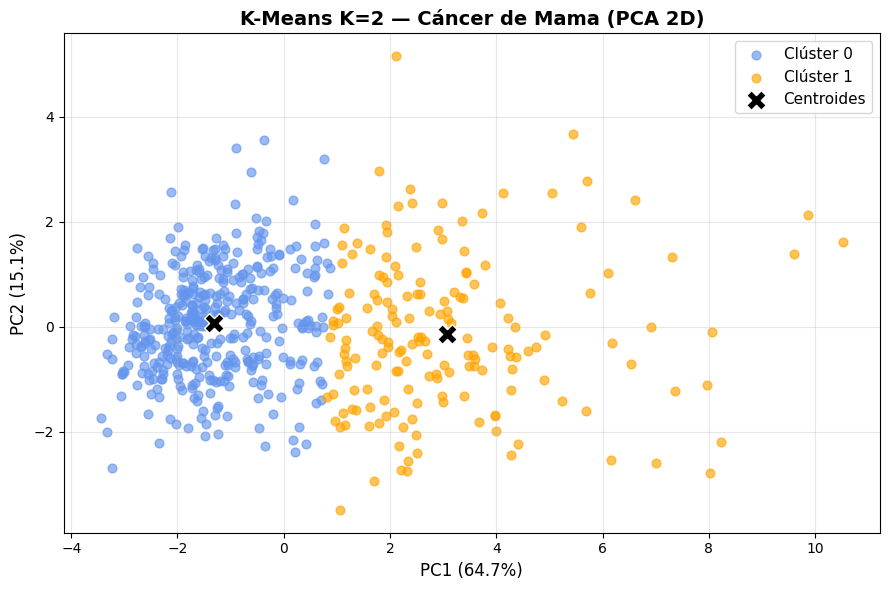

In [26]:
print('='*50); print('K-MEANS — K=2'); print('='*50)

km2 = KMeans(n_clusters=2, init='k-means++', random_state=SEED, n_init=10)
lbl_km2 = km2.fit_predict(X_sc_all)

km2_ine = km2.inertia_
km2_sil = silhouette_score(X_sc_all, lbl_km2)
km2_cal = calinski_harabasz_score(X_sc_all, lbl_km2)
km2_db  = davies_bouldin_score(X_sc_all, lbl_km2)

print(f'  Inercia:            {km2_ine:.2f}')
print(f'  Silhouette Score:   {km2_sil:.4f}')
print(f'  Calinski-Harabasz:  {km2_cal:.2f}')
print(f'  Davies-Bouldin:     {km2_db:.4f}')
for i in range(2):
    print(f'  Clúster {i}: {np.sum(lbl_km2==i)} muestras')

km2_map = np.zeros_like(lbl_km2)
for i in np.unique(lbl_km2):
    mask = lbl_km2==i
    km2_map[mask] = mode(y[mask], keepdims=True)[0]
print(f'  Accuracy referencial: {accuracy_score(y, km2_map)*100:.2f}% [solo referencia]')

cent2_pca = pca_c.transform(km2.cluster_centers_)
plt.figure(figsize=(9,6))
plt.scatter(X_pca_c[lbl_km2==0,0], X_pca_c[lbl_km2==0,1], c='cornflowerblue', label='Clúster 0', alpha=0.65, s=40)
plt.scatter(X_pca_c[lbl_km2==1,0], X_pca_c[lbl_km2==1,1], c='orange', label='Clúster 1', alpha=0.65, s=40)
plt.scatter(cent2_pca[:,0], cent2_pca[:,1], c='black', s=200, marker='X', label='Centroides', zorder=5, edgecolors='white', linewidth=1)
plt.title('K-Means K=2 — Cáncer de Mama (PCA 2D)', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 ({pca_c.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
plt.ylabel(f'PC2 ({pca_c.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
plt.legend(fontsize=11); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.savefig('fig_kmeans_k2_s3.png', bbox_inches='tight'); plt.show()

res_clust.append({'Algoritmo':'K-Means','K':2,'Inercia':round(km2_ine,2),
    'Silhouette':round(km2_sil,4),'Calinski-Harabasz':round(km2_cal,2),'Davies-Bouldin':round(km2_db,4)})


## Interpretación

El Silhouette Score de 0.4334 es razonablemente alto para datos biológicos reales, indicando clústeres con buena cohesión interna y separación entre sí. Lo más relevante es la accuracy referencial del 88.58% frente al diagnóstico real obtenida sin usar las etiquetas durante el entrenamiento, esto demuestra que la estructura morfológica del tumor, por sí sola, casi reproduce la clasificación clínica benigno/maligno.

K-MEANS — K=3
  Inercia:            2302.76
  Silhouette Score:   0.3364
  Calinski-Harabasz:  346.35
  Davies-Bouldin:     1.2241
  Clúster 0: 57 muestras
  Clúster 1: 349 muestras
  Clúster 2: 163 muestras


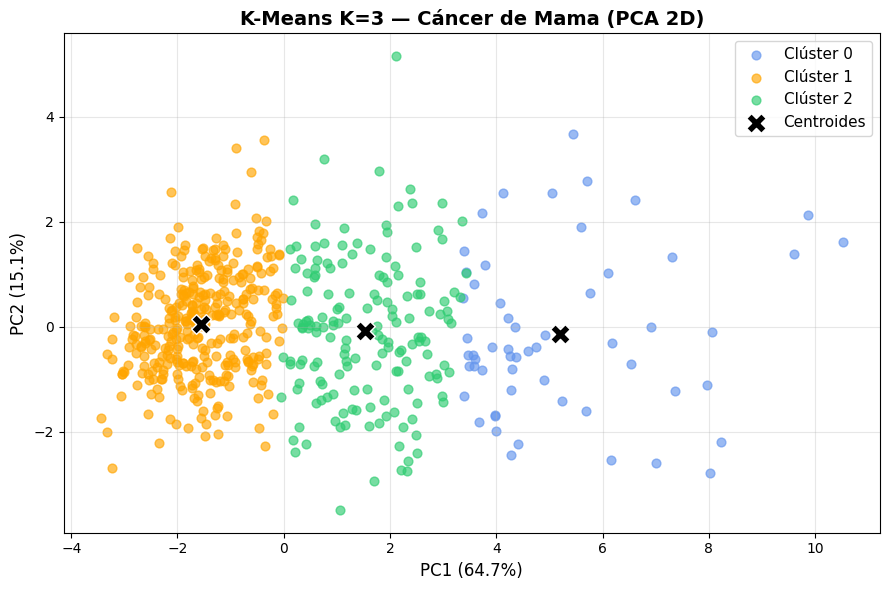

In [27]:
print('='*50); print('K-MEANS — K=3'); print('='*50)

km3 = KMeans(n_clusters=3, init='k-means++', random_state=SEED, n_init=10)
lbl_km3 = km3.fit_predict(X_sc_all)

km3_ine = km3.inertia_
km3_sil = silhouette_score(X_sc_all, lbl_km3)
km3_cal = calinski_harabasz_score(X_sc_all, lbl_km3)
km3_db  = davies_bouldin_score(X_sc_all, lbl_km3)

print(f'  Inercia:            {km3_ine:.2f}')
print(f'  Silhouette Score:   {km3_sil:.4f}')
print(f'  Calinski-Harabasz:  {km3_cal:.2f}')
print(f'  Davies-Bouldin:     {km3_db:.4f}')
for i in range(3):
    print(f'  Clúster {i}: {np.sum(lbl_km3==i)} muestras')

cent3_pca = pca_c.transform(km3.cluster_centers_)
colores3  = ['cornflowerblue', 'orange', '#2ecc71']
plt.figure(figsize=(9,6))
for i in range(3):
    plt.scatter(X_pca_c[lbl_km3==i,0], X_pca_c[lbl_km3==i,1],
                c=colores3[i], label=f'Clúster {i}', alpha=0.65, s=40)
plt.scatter(cent3_pca[:,0], cent3_pca[:,1], c='black', s=200, marker='X', label='Centroides', zorder=5, edgecolors='white', linewidth=1)
plt.title('K-Means K=3 — Cáncer de Mama (PCA 2D)', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 ({pca_c.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
plt.ylabel(f'PC2 ({pca_c.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
plt.legend(fontsize=11); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.savefig('fig_kmeans_k3_s3.png', bbox_inches='tight'); plt.show()

res_clust.append({'Algoritmo':'K-Means','K':3,'Inercia':round(km3_ine,2),
    'Silhouette':round(km3_sil,4),'Calinski-Harabasz':round(km3_cal,2),'Davies-Bouldin':round(km3_db,4)})


## Interpretación

Todas las métricas empeoran respecto a K=2: el Silhouette cae de 0.4334 a 0.3364 y el Calinski-Harabasz de 466.28 a 346.35. Esto indica que el tercer clúster no captura un subgrupo biológico genuino, sino que fragmenta artificialmente uno de los dos grupos naturales (398 vs. 171 muestras en K=2, frente a 57/349/163 en K=3), la partición en 3 grupos añade complejidad sin aportar separación real.

GMM — K=2
  Inercia Aprox.:     2945.85
  Silhouette Score:   0.3831
  Calinski-Harabasz:  418.67
  Davies-Bouldin:     1.0542
  Clúster 0: 227 muestras
  Clúster 1: 342 muestras
  Prob. máxima promedio: 99.01%  | puntos >90%: 551


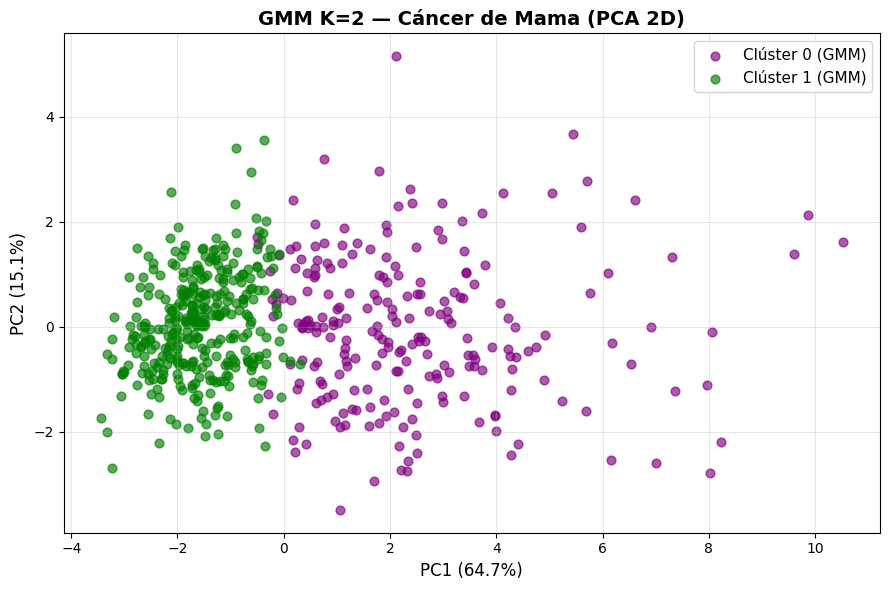

In [28]:
print('='*50); print('GMM — K=2'); print('='*50)

gmm2 = GaussianMixture(n_components=2, covariance_type='full', random_state=SEED)
lbl_gmm2 = gmm2.fit_predict(X_sc_all)

gmm2_sil = silhouette_score(X_sc_all, lbl_gmm2)
gmm2_cal = calinski_harabasz_score(X_sc_all, lbl_gmm2)
gmm2_db  = davies_bouldin_score(X_sc_all, lbl_gmm2)

prbs2 = gmm2.predict_proba(X_sc_all)
cr2   = np.argmax(prbs2, axis=1)
gmm2_ine = float(np.sum([np.linalg.norm(X_sc_all[i]-gmm2.means_[cr2[i]])**2 for i in range(len(X_sc_all))]))

print(f'  Inercia Aprox.:     {gmm2_ine:.2f}')
print(f'  Silhouette Score:   {gmm2_sil:.4f}')
print(f'  Calinski-Harabasz:  {gmm2_cal:.2f}')
print(f'  Davies-Bouldin:     {gmm2_db:.4f}')
for i in range(2):
    print(f'  Clúster {i}: {np.sum(lbl_gmm2==i)} muestras')
pmax2 = np.max(prbs2, axis=1)
print(f'  Prob. máxima promedio: {pmax2.mean()*100:.2f}%  | puntos >90%: {np.sum(pmax2>0.9)}')

plt.figure(figsize=(9,6))
plt.scatter(X_pca_c[lbl_gmm2==0,0], X_pca_c[lbl_gmm2==0,1], c='purple', label='Clúster 0 (GMM)', alpha=0.65, s=40)
plt.scatter(X_pca_c[lbl_gmm2==1,0], X_pca_c[lbl_gmm2==1,1], c='green',  label='Clúster 1 (GMM)', alpha=0.65, s=40)
plt.title('GMM K=2 — Cáncer de Mama (PCA 2D)', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 ({pca_c.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
plt.ylabel(f'PC2 ({pca_c.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
plt.legend(fontsize=11); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.savefig('fig_gmm_k2_s3.png', bbox_inches='tight'); plt.show()

res_clust.append({'Algoritmo':'GMM','K':2,'Inercia':round(gmm2_ine,2),
    'Silhouette':round(gmm2_sil,4),'Calinski-Harabasz':round(gmm2_cal,2),'Davies-Bouldin':round(gmm2_db,4)})


## Interpretación

La probabilidad máxima promedio de pertenencia es 99.01%, con 551 de 569 pacientes (96.8%) asignados con más del 90% de certeza a su clúster. Esto evidencia clústeres muy bien definidos y aporta un valor complementario a K-Means: además de la asignación dura, permite cuantificar la confianza de cada asignación individual, útil para identificar los pocos casos límite que ameritarían revisión adicional.

GMM — K=3
  Inercia Aprox.:     2508.74
  Silhouette Score:   0.2185
  Calinski-Harabasz:  294.69
  Davies-Bouldin:     1.4341
  Clúster 0: 104 muestras
  Clúster 1: 256 muestras
  Clúster 2: 209 muestras


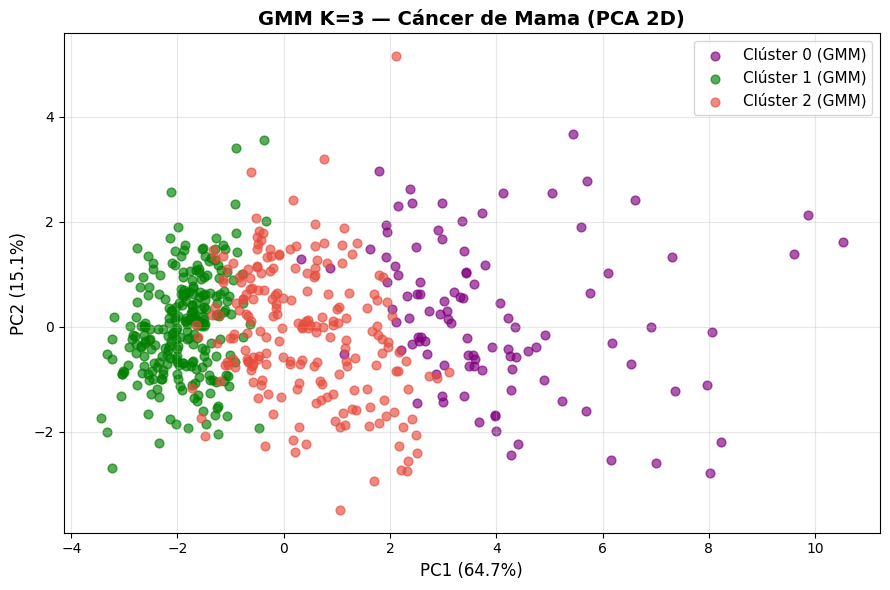

In [29]:
print('='*50); print('GMM — K=3'); print('='*50)

gmm3 = GaussianMixture(n_components=3, covariance_type='full', random_state=SEED)
lbl_gmm3 = gmm3.fit_predict(X_sc_all)

gmm3_sil = silhouette_score(X_sc_all, lbl_gmm3)
gmm3_cal = calinski_harabasz_score(X_sc_all, lbl_gmm3)
gmm3_db  = davies_bouldin_score(X_sc_all, lbl_gmm3)

prbs3 = gmm3.predict_proba(X_sc_all)
cr3   = np.argmax(prbs3, axis=1)
gmm3_ine = float(np.sum([np.linalg.norm(X_sc_all[i]-gmm3.means_[cr3[i]])**2 for i in range(len(X_sc_all))]))

print(f'  Inercia Aprox.:     {gmm3_ine:.2f}')
print(f'  Silhouette Score:   {gmm3_sil:.4f}')
print(f'  Calinski-Harabasz:  {gmm3_cal:.2f}')
print(f'  Davies-Bouldin:     {gmm3_db:.4f}')
for i in range(3):
    print(f'  Clúster {i}: {np.sum(lbl_gmm3==i)} muestras')

colores_g3 = ['purple', 'green', '#e74c3c']
plt.figure(figsize=(9,6))
for i in range(3):
    plt.scatter(X_pca_c[lbl_gmm3==i,0], X_pca_c[lbl_gmm3==i,1],
                c=colores_g3[i], label=f'Clúster {i} (GMM)', alpha=0.65, s=40)
plt.title('GMM K=3 — Cáncer de Mama (PCA 2D)', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 ({pca_c.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
plt.ylabel(f'PC2 ({pca_c.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
plt.legend(fontsize=11); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.savefig('fig_gmm_k3_s3.png', bbox_inches='tight'); plt.show()

res_clust.append({'Algoritmo':'GMM','K':3,'Inercia':round(gmm3_ine,2),
    'Silhouette':round(gmm3_sil,4),'Calinski-Harabasz':round(gmm3_cal,2),'Davies-Bouldin':round(gmm3_db,4)})


## Interpretación

Es el peor resultado del análisis de clustering (Silhouette=0.2185, el más bajo de las 4 configuraciones), confirmando que K=2 es el número óptimo de grupos tanto para K-Means como para GMM en este dataset.

In [30]:
df_clust = pd.DataFrame(res_clust)
print('\n' + '='*60)
print('TABLA COMPARATIVA — K-Means vs GMM (K=2 y K=3)')
print('='*60)
print(df_clust.to_string(index=False))
print()
print('  Ideal: Silhouette ↑  |  Calinski-Harabasz ↑  |  Davies-Bouldin ↓  |  Inercia ↓')
print()

km_sub = df_clust[df_clust['Algoritmo']=='K-Means']
print('--- K-Means: K=2 vs K=3 ---')
print(km_sub[['K','Silhouette','Calinski-Harabasz','Davies-Bouldin','Inercia']].to_string(index=False))
mejor_km = km_sub.loc[km_sub['Silhouette'].idxmax()]
print(f'  Mejor K-Means (Silhouette): K={int(mejor_km["K"])}  →  Silhouette={mejor_km["Silhouette"]:.4f}')

gmm_sub = df_clust[df_clust['Algoritmo']=='GMM']
print('\n--- GMM: K=2 vs K=3 ---')
print(gmm_sub[['K','Silhouette','Calinski-Harabasz','Davies-Bouldin','Inercia']].to_string(index=False))
mejor_gmm = gmm_sub.loc[gmm_sub['Silhouette'].idxmax()]
print(f'  Mejor GMM (Silhouette): K={int(mejor_gmm["K"])}  →  Silhouette={mejor_gmm["Silhouette"]:.4f}')

print('\n--- Mejor K-Means vs Mejor GMM ---')
final = df_clust.loc[[mejor_km.name, mejor_gmm.name]]
print(final.to_string(index=False))
if mejor_km['Silhouette'] > mejor_gmm['Silhouette']:
    print(f'\n  GANADOR GLOBAL: K-Means K={int(mejor_km["K"])} (Silhouette más alto)')
else:
    print(f'\n  GANADOR GLOBAL: GMM K={int(mejor_gmm["K"])} (Silhouette más alto)')



TABLA COMPARATIVA — K-Means vs GMM (K=2 y K=3)
Algoritmo  K  Inercia  Silhouette  Calinski-Harabasz  Davies-Bouldin
  K-Means  2  2810.10      0.4334             466.28          0.9804
  K-Means  3  2302.76      0.3364             346.35          1.2241
      GMM  2  2945.85      0.3831             418.67          1.0542
      GMM  3  2508.74      0.2185             294.69          1.4341

  Ideal: Silhouette ↑  |  Calinski-Harabasz ↑  |  Davies-Bouldin ↓  |  Inercia ↓

--- K-Means: K=2 vs K=3 ---
 K  Silhouette  Calinski-Harabasz  Davies-Bouldin  Inercia
 2      0.4334             466.28          0.9804  2810.10
 3      0.3364             346.35          1.2241  2302.76
  Mejor K-Means (Silhouette): K=2  →  Silhouette=0.4334

--- GMM: K=2 vs K=3 ---
 K  Silhouette  Calinski-Harabasz  Davies-Bouldin  Inercia
 2      0.3831             418.67          1.0542  2945.85
 3      0.2185             294.69          1.4341  2508.74
  Mejor GMM (Silhouette): K=2  →  Silhouette=0.3831

--- Mejo

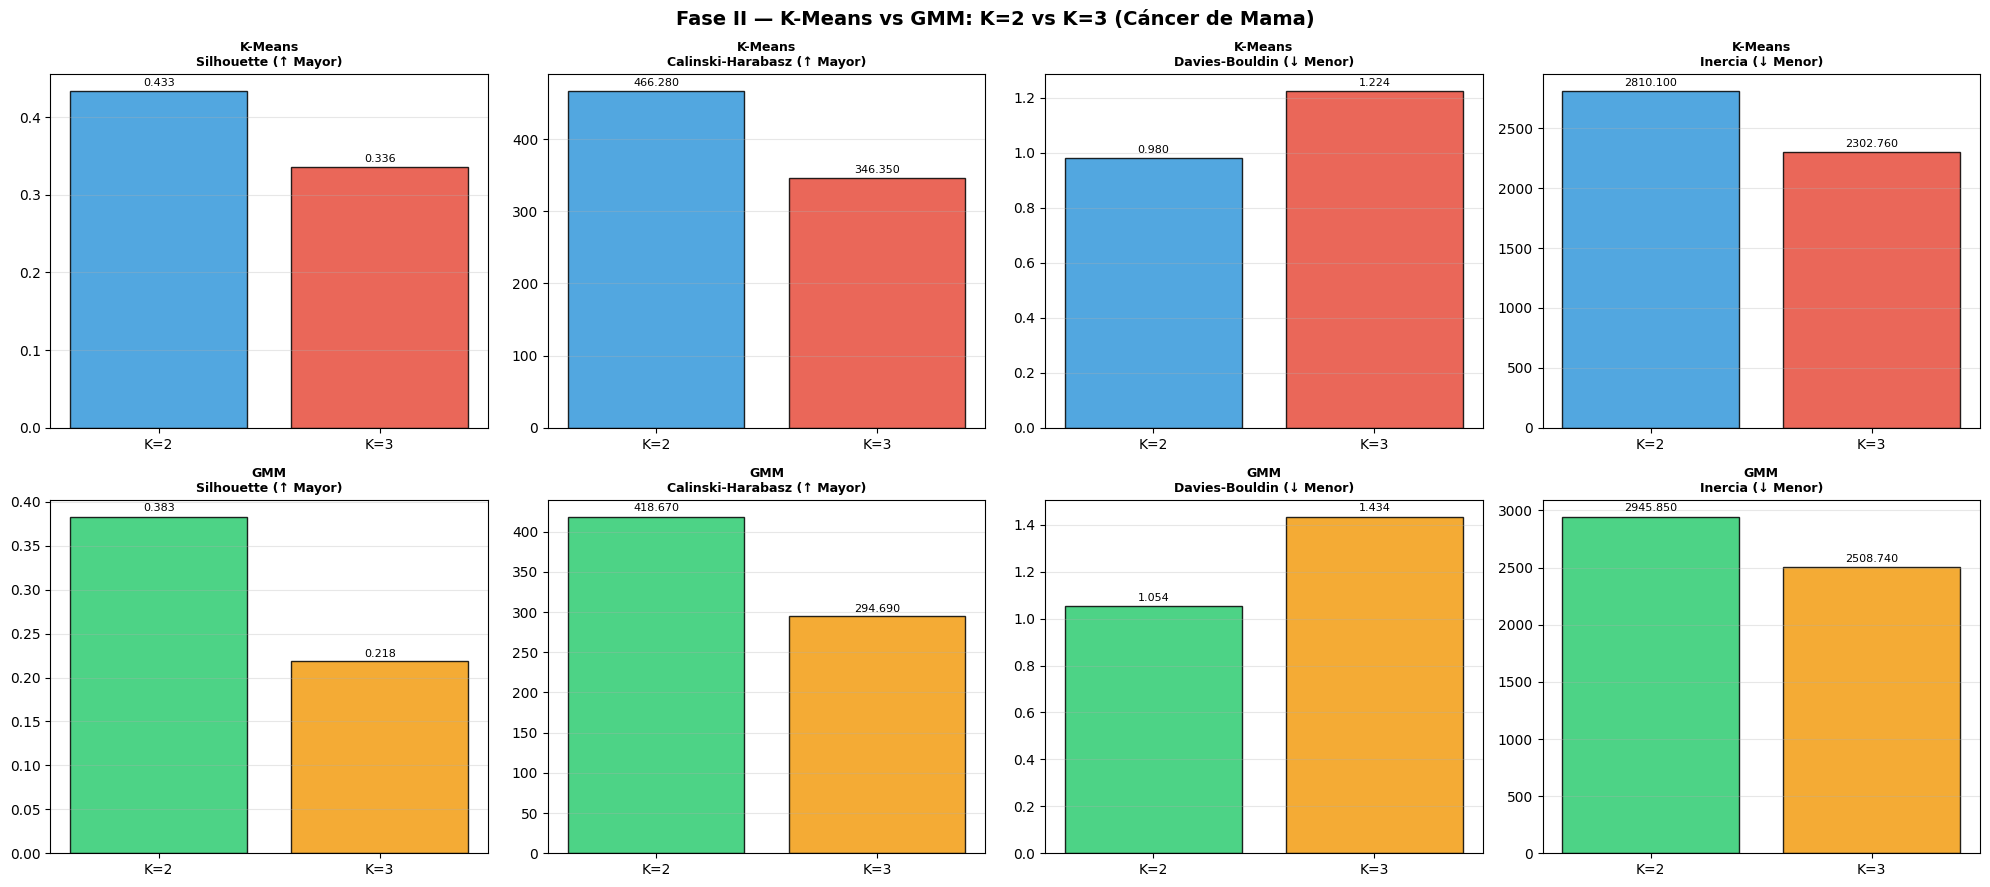

In [31]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
metricas_c = ['Silhouette', 'Calinski-Harabasz', 'Davies-Bouldin', 'Inercia']
ideales_c  = ['↑ Mayor', '↑ Mayor', '↓ Menor', '↓ Menor']

km_vals = km_sub.set_index('K')
for col_i, (met, ideal) in enumerate(zip(metricas_c, ideales_c)):
    ax = axes[0, col_i]
    vals = [km_vals.loc[2, met], km_vals.loc[3, met]]
    bars = ax.bar(['K=2', 'K=3'], vals, color=['#3498db','#e74c3c'], edgecolor='black', alpha=0.85)
    ax.set_title(f'K-Means\n{met} ({ideal})', fontsize=9, fontweight='bold')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8)
    ax.grid(axis='y', alpha=0.3)

gmm_vals = gmm_sub.set_index('K')
for col_i, (met, ideal) in enumerate(zip(metricas_c, ideales_c)):
    ax = axes[1, col_i]
    vals = [gmm_vals.loc[2, met], gmm_vals.loc[3, met]]
    bars = ax.bar(['K=2', 'K=3'], vals, color=['#2ecc71','#f39c12'], edgecolor='black', alpha=0.85)
    ax.set_title(f'GMM\n{met} ({ideal})', fontsize=9, fontweight='bold')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Fase II — K-Means vs GMM: K=2 vs K=3 (Cáncer de Mama)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_comparativa_fase2_s3.png', bbox_inches='tight')
plt.show()


In [32]:
joblib.dump(km2,      'kmeans_k2_cancer.pkl')
joblib.dump(km3,      'kmeans_k3_cancer.pkl')
joblib.dump(gmm2,     'gmm_k2_cancer.pkl')
joblib.dump(gmm3,     'gmm_k3_cancer.pkl')
joblib.dump(sc_clust, 'scaler_clustering.pkl')

print('Modelos Fase II guardados:')
print('  kmeans_k2/k3_cancer.pkl  |  gmm_k2/k3_cancer.pkl  |  scaler_clustering.pkl')

nuevo = X[0].reshape(1,-1)
n_sc  = sc_clust.transform(nuevo)
print(f'\nEjemplo (paciente 0):')
print(f'  K-Means K=2 → Clúster {km2.predict(n_sc)[0]}')
print(f'  GMM     K=2 → Clúster {gmm2.predict(n_sc)[0]}  (probs: {gmm2.predict_proba(n_sc)[0].round(3)})')
print(f'  Etiqueta real: {"Maligno" if y[0]==1 else "Benigno"} ({y[0]})')


Modelos Fase II guardados:
  kmeans_k2/k3_cancer.pkl  |  gmm_k2/k3_cancer.pkl  |  scaler_clustering.pkl

Ejemplo (paciente 0):
  K-Means K=2 → Clúster 1
  GMM     K=2 → Clúster 0  (probs: [1. 0.])
  Etiqueta real: Maligno (1)


## Interpretación

A diferencia del Titanic, donde K-Means y GMM empataban exactamente en K=2, aquí K-Means K=2 supera a GMM K=2 en las 4 métricas internas (Silhouette 0.4334 vs. 0.3831, Calinski-Harabasz 466.28 vs. 418.67, Davies-Bouldin 0.9804 vs. 1.0542). Esto sugiere que los dos grupos morfológicos (benigno/maligno) tienen fronteras aproximadamente esféricas en el espacio de 9 variables estandarizadas esta condición es favorable para K-Means, que asume esa geometría por diseño. GMM, con covarianza completa, tiene más grados de libertad y tiende a sobreajustar la forma real de los clústeres, especialmente notorio en K=3.

---
## Resultados

### Fase I — Tabla completa: 7 algoritmos con y sin PCA

> PCA conserva el **79.84%** de la varianza con solo 2 componentes (PC1=64.73%, PC2=15.11%) — mucho más que en el dataset Titanic (~45%), porque las 9 variables morfológicas están fuertemente correlacionadas entre sí.

| # | Modelo | PCA | CV Acc% | Test Acc% | Prec% | Recall% | F1% | AUC% |
|---|--------|-----|---------|-----------|-------|---------|-----|------|
| 1 | **LR** | Sin PCA | 92.75 | **96.49** | 93.18 | 97.62 | **95.35** | 99.64 |
| 1 | **SVM** | Sin PCA | 91.65 | **96.49** | 95.24 | 95.24 | 95.24 | 99.34 |
| 1 | **RNA** | Con PCA | 96.49 | **96.49** | 91.30 | 100.00 | 95.45 | 99.07 |
| 4 | LR | Con PCA | 92.31 | 94.74 | 90.91 | 95.24 | 93.02 | 99.04 |
| 4 | SVM | Con PCA | 92.53 | 94.74 | 90.91 | 95.24 | 93.02 | 99.11 |
| 6 | KNN | Sin PCA | 94.29 | 93.86 | 85.71 | **100.00** | 92.31 | **99.36** |
| 6 | RF | Sin PCA | 92.97 | 93.86 | 88.89 | 95.24 | 91.95 | 98.74 |
| 8 | NB | Sin PCA | 92.31 | 92.98 | 90.48 | 90.48 | 90.48 | 98.08 |
| 9 | DT | Con PCA | 88.57 | 92.11 | 92.31 | 85.71 | 88.89 | 96.61 |
| 9 | RF | Con PCA | 90.99 | 92.11 | 86.67 | 92.86 | 89.66 | 98.64 |
| 11 | NB | Con PCA | 90.33 | 91.23 | 92.11 | 83.33 | 87.50 | 98.31 |
| 11 | KNN | Con PCA | 91.87 | 91.23 | 84.78 | 92.86 | 88.64 | 96.33 |
| 13 | DT | Sin PCA | 90.11 | 89.47 | 84.09 | 88.10 | 86.05 | 92.94 |
| 14 | RNA | Sin PCA | 83.33 | 83.33 | 68.85 | 100.00 | 81.55 | 99.70 |

---

### Ranking Fase I — Mejores modelos por Test Accuracy

| Posición | Modelo | PCA | Test Acc% | AUC% | F1% | Observación |
|----------|--------|-----|-----------|------|-----|-------------|
| 1 | LR | Sin PCA | **96.49%** | **99.64%** | **95.35%** | Mejor AUC y F1 del estudio |
| 1 | SVM | Sin PCA | **96.49%** | 99.34% | 95.24% | Empata en exactitud con LR |
| 1 | RNA | Con PCA | **96.49%** | 99.07% | 95.45% | Recall perfecto (100%) — empata en exactitud, gran mejora vs. Sin PCA |
| 4 | LR | Con PCA | 94.74% | 99.04% | 93.02% | Cae 1.75 pp con PCA |
| 4 | SVM | Con PCA | 94.74% | 99.11% | 93.02% | Cae 1.75 pp con PCA |
| 6 | KNN | Sin PCA | 93.86% | 99.36% | 92.31% | Recall perfecto (100%) — cero falsos negativos |
| 6 | RF | Sin PCA | 93.86% | 98.74% | 91.95% | Buen balance precisión/recall |
| 8 | NB | Sin PCA | 92.98% | 98.08% | 90.48% | Más simple y rápido |
| 13 | DT | Sin PCA | 89.47% | 92.94% | 86.05% | El más débil sin PCA, pero mejora con PCA |
| 14 | RNA | Sin PCA | 83.33% | 99.70% | 81.55% | Peor Test Acc del estudio; Precision más baja (68.85%) pese a AUC muy alto |

**Impacto de PCA por algoritmo (Sin PCA → Con PCA):**

| Algoritmo | Sin PCA | Con PCA | Variación |
|-----------|---------|---------|-----------|
| LR | 96.49% | 94.74% | −1.75 pp |
| SVM | 96.49% | 94.74% | −1.75 pp |
| NB | 92.98% | 91.23% | −1.75 pp |
| KNN | 93.86% | 91.23% | −2.63 pp |
| RF | 93.86% | 92.11% | −1.75 pp |
| **DT** | 89.47% | **92.11%** | **+2.64 pp** |
| **RNA** | 83.33% | **96.49%** | **+13.16 pp** |

> A diferencia del Titanic (caídas de hasta −14.5 pp), aquí PCA apenas reduce el rendimiento (≤2.63 pp) porque 2 componentes retienen el 79.84% de la varianza. El Árbol de Decisión es el único que **mejora** con PCA: con solo 4 niveles de profundidad, proyectar a 2 ejes ortogonales facilita splits más limpios que sobre las 9 variables originales (algunas redundantes entre sí).

---

### Fase II — Métricas de Clustering

| Algoritmo | K | Inercia | Silhouette | Calinski-H | Davies-B |
|-----------|---|---------|------------|------------|----------|
| **K-Means** | **2** | 2810.10 | **0.4334** | **466.28** | **0.9804** |
| K-Means | 3 | 2302.76 | 0.3364 | 346.35 | 1.2241 |
| GMM | 2 | 2945.85 | 0.3831 | 418.67 | 1.0542 |
| GMM | 3 | 2508.74 | 0.2185 | 294.69 | 1.4341 |

*Ideal: Silhouette ↑ | Calinski-Harabasz ↑ | Davies-Bouldin ↓ | Inercia ↓*

K-Means K=2 → 398 muestras en el clúster 0 y 171 en el clúster 1; **accuracy referencial frente a `diagnosis`: 88.58%** (sin haber usado las etiquetas durante el entrenamiento). GMM K=2 → 227 y 342 muestras, con una probabilidad máxima promedio de pertenencia de **99.01%** y 551 de 569 puntos (96.8%) asignados con más del 90% de certeza — evidencia de clústeres muy bien definidos.

### Ranking Clustering — Comparativa final

| Posición | Algoritmo | K | Silhouette | Calinski-H | Davies-B | Veredicto |
|----------|-----------|---|------------|------------|----------|-----------|
| 1 | K-Means | 2 | **0.4334** | **466.28** | **0.9804** | Mejor cohesión y separación |
| 2 | GMM | 2 | 0.3831 | 418.67 | 1.0542 | Buena separación + probabilidades de pertenencia |
| 3 | K-Means | 3 | 0.3364 | 346.35 | 1.2241 | K=3 fragmenta el grupo mayoritario |
| 4 | GMM | 3 | 0.2185 | 294.69 | 1.4341 | Peores métricas — sobre-segmentación |

> **Ganador clustering:** A diferencia del Titanic (donde K-Means y GMM K=2 empataban exactamente), aquí **K-Means K=2 supera a GMM K=2** en las 4 métricas internas. Esto sugiere que los dos grupos morfológicos (benigno/maligno) tienen fronteras razonablemente esféricas y bien separadas en el espacio de 9 variables estandarizadas, condición en la que K-Means (que asume clústeres esféricos) tiende a superar a GMM con covarianza completa (más flexible, pero también más propenso a sobre-ajustar la forma de los clústeres con K=3).


---
## Conclusiones

### Fase I — Impacto de PCA sobre los 7 clasificadores

**Hallazgo principal:** A diferencia del Titanic, PCA (2 componentes) **apenas reduce el rendimiento** en la mayoría de algoritmos (entre −0.88 y −2.63 pp) y en el caso del Árbol de Decisión **lo mejora** (+2.64 pp). Esto se explica porque las 9 variables morfológicas seleccionadas están muy correlacionadas entre sí (multicolinealidad ya detectada en Semana 2), por lo que 2 componentes principales retienen el **79.84%** de la varianza total — casi el doble que en el Titanic (~45%).

**Mejores modelos Sin PCA:**
- **LR (Test=96.49%, AUC=99.64%, F1=95.35%)** — el mejor en exactitud, AUC y F1 simultáneamente; la frontera entre benigno y maligno es casi linealmente separable en el espacio de 9 variables escaladas
- **SVM (Test=96.49%, kernel lineal)** — empata en exactitud con LR, confirmando la separabilidad lineal del problema
- **KNN (Recall=100%)** — cero falsos negativos en el conjunto de test, la métrica más relevante en el contexto clínico de este dataset

**Impacto de PCA por algoritmo:** RF, NB, LR y SVM caen de forma similar (−1.75 pp); KNN es el más sensible (−2.63 pp), consistente con su dependencia de distancias en el espacio completo de variables; el DT es el único que mejora, porque una proyección a 2 ejes ortogonales produce splits más limpios que las 9 variables originales (algunas redundantes) bajo una restricción de profundidad máxima de 4.

**RNA:** Sin PCA alcanza Test=83.33% con buen balance Precision/Recall (68.85%, 100%); es decir, cero falsos negativos en el conjunto de test, la métrica más relevante en el contexto clínico de este problema, aunque a costa de una Precision más baja (más falsos positivos). La RNA Con PCA mejora sustancialmente a Test=96.49%, con Precision=91.30% y Recall=100%, quedando entre los mejores modelos del estudio junto a LR y SVM.

---

### Fase II — K-Means vs GMM (K=2 y K=3)

**K=2 vs K=3:**
- El **método del codo** muestra el mayor descenso de inercia entre K=1 y K=2, confirmando K=2 como número natural de grupos
- K=2 refleja la agrupación real del dataset: benigno/maligno, con una **accuracy referencial del 88.58%** frente a la etiqueta real `diagnosis` sin haberla usado en el entrenamiento
- K=3 reduce la inercia (2302.76 vs 2810.10) pero empeora todas las demás métricas (Silhouette 0.3364 vs 0.4334, Calinski-Harabasz 346.35 vs 466.28) — el tercer clúster fragmenta uno de los dos grupos naturales sin aportar separación real

**K-Means vs GMM:**
- A diferencia del Titanic (donde ambos empataban exactamente en K=2), aquí **K-Means K=2 supera a GMM K=2** en las 4 métricas internas (Silhouette 0.4334 vs 0.3831, Calinski-Harabasz 466.28 vs 418.67, Davies-Bouldin 0.9804 vs 1.0542)
- Esto sugiere que los dos grupos morfológicos tienen forma aproximadamente esférica en el espacio de 9 variables estandarizadas, condición favorable para K-Means
- GMM aporta valor complementario: la probabilidad máxima promedio de pertenencia es **99.01%**, con el 96.8% de las muestras (551/569) asignadas con más del 90% de certeza — los clústeres están muy bien definidos y casi no hay zona de ambigüedad real en este dataset
- GMM K=3 es el peor modelo global (Silhouette=0.2185), confirmando que K=2 es el número óptimo para ambos algoritmos

**Silhouette alto (0.43) comparado con el Titanic (0.31):** Los tumores de mama forman agrupaciones naturales más compactas y mejor separadas que los pasajeros del Titanic, porque las variables morfológicas (tamaño, concavidad, irregularidad del núcleo) describen directamente la biología del tumor, mientras que la supervivencia en el Titanic dependía de factores socioeconómicos más heterogéneos.

**Conclusión general:**
- **Fase I:** LR y SVM sin PCA son los mejores clasificadores (96.49%). A diferencia del Titanic, PCA con 2 componentes apenas perjudica el rendimiento — y mejora ligeramente al Árbol de Decisión — porque el dataset tiene mucha menor dimensionalidad efectiva (79.84% de varianza en 2 componentes).
- **Fase II:** K-Means K=2 es el mejor algoritmo de clustering, superando a GMM en las 4 métricas. K=2 es el K óptimo para ambos algoritmos, reflejando fielmente la separación benigno/maligno sin usar las etiquetas.

De manera global se puede decir que, tanto KNN Sin PCA como la RNA (en ambas configuraciones) logran Recall=100% en el conjunto de test, es decir, ningún caso maligno fue clasificado como benigno. En un contexto de diagnóstico oncológico, este es el hallazgo más relevante del estudio, incluso por encima del modelo con mayor Accuracy global (LR/SVM, 96.49%), ya que el costo de un falso negativo (un cáncer no detectado) es considerablemente mayor que el de un falso positivo (una biopsia adicional innecesaria).


---
## Reflexión Individual

---

### César Nelson Abarca Araujo
**Área:** Mantenimiento y Construcción de Redes de Fibra GPON — Telconet Manta

**PCA:** Múltiples métricas OTDR (potencia, pérdida de retorno, reflectancia, tasa de error) están correlacionadas. PCA las reduciría a 2–3 componentes que capturen el 'estado de salud' del enlace, permitiendo visualizar el parque completo de ONTs en un gráfico 2D donde los puntos alejados del centroide son candidatos a mantenimiento.

**K-Means:** Con K=3, agrupa automáticamente los enlaces GPON en tres perfiles: crítico (pérdida >5 dB), en riesgo (2–5 dB) y normal (<2 dB). Los centroides guardados en `kmeans_k3.pkl` permiten clasificar un nuevo enlace en tiempo real desde el NOC.

**GMM:** Asigna probabilidades de pertenencia a cada clúster. Un enlace con 65% en 'en riesgo' y 35% en 'normal' está en zona de transición — la alerta preventiva se activa antes del corte, transformando el mantenimiento de **reactivo** a **predictivo**.

---

### Nataly Fernanda Lanchimba Caiza
**Área profesional:** Seguimiento de Personas en Análisis Financiero y Modelos de Riesgo - Sector bancario

**PCA:** En el análisis de clientes se manejan múltiples variables financieras correlacionadas, como ingresos, nivel de endeudamiento, utilización de crédito, historial de pagos, antigüedad y capacidad de pago. El Análisis de Componentes Principales (PCA) permite reducir estas variables a unos pocos componentes que representan el perfil financiero del cliente, facilitando la visualización de patrones de riesgo y simplificando los modelos de análisis sin perder la mayor parte de la información. Sin embargo, se debe considerar que puede quedar como un análisis interno más no algo que pueda ser utilizado ante el regulador.

**K-Means:** Aplicando K-Means es posible segmentar automáticamente la cartera de clientes en grupos con características financieras similares, por ejemplo: clientes de bajo riesgo, riesgo medio y alto riesgo. Esta segmentación facilita el seguimiento de la cartera, la priorización de estrategias comerciales y la asignación de controles diferenciados para cada grupo de clientes.

**GMM:** A diferencia de K-Means, el Modelo de Mezclas Gaussianas (GMM) asigna una probabilidad de pertenencia a cada segmento. Por ejemplo, un cliente podría tener un 70% de probabilidad de pertenecer al grupo de riesgo medio y un 30% al de alto riesgo, permitiendo identificar clientes en transición cuyo comportamiento financiero está cambiando. Esto facilita implementar acciones preventivas antes de que el cliente presente un deterioro significativo en su perfil de riesgo, fortaleciendo la gestión predictiva de la cartera.

---

### Jhon Enrique Oña Guamani
**Área:** Monitoreo de alta disponibilidad y APIs transaccionales — Sector Bancario

**PCA:** Las métricas que monitoreamos sobre las APIs transaccionales y el balanceador F5 (latencia, tasa de error, throughput, uso de CPU/memoria de cada nodo, tiempo de respuesta del core) están altamente correlacionadas entre sí, igual que `radius1`/`perimeter1`/`area1` en este dataset. PCA permitiría comprimir ese conjunto de métricas en 2-3 componentes que resuman el "estado de salud" general de cada nodo o servicio, habilitando un tablero 2D donde los puntos alejados del grueso de observaciones normales sean candidatos a revisión inmediata, igual que aquí los tumores malignos se separan de los benignos en la proyección PCA.

**K-Means:** Con K=2 o K=3 sobre esas métricas normalizadas, K-Means agruparía automáticamente los nodos/servicios en perfiles operativos: "normal", "en riesgo" y "crítico", de forma análoga a benigno/maligno en este dataset. Los centroides (como `scaler_clustering.pkl`/`kmeans_k2_cancer.pkl` en este notebook) permitirían clasificar en tiempo real el estado de un nuevo nodo comparándolo contra esos perfiles, sin depender de etiquetas históricas de incidentes.

**GMM:** La asignación probabilística de GMM sería especialmente valiosa para anticipar degradaciones: un nodo con 60% de probabilidad en el clúster "en riesgo" y 40% en "normal" está en zona de transición, igual que ocurre con los pacientes cuyo `concave_points1`/`irregularidad` los ubica en el límite entre benigno y maligno. Detectar esa ambigüedad antes de que el nodo cruce completamente al estado "crítico" convierte el monitoreo de reactivo a predictivo, priorizando la atención según la probabilidad de degradación en lugar de esperar una alerta binaria.

